# Clinical feature extraction for poorly distinguished SERS patients

This notebook extracts clinical characteristics from the operational PostgreSQL database for OOF errors and near-threshold patients. OOF predictions and QC/noise summaries remain frozen model-run artifacts; original identifiers are used only for the in-memory join and are not written to outputs.

## TL;DR

The primary comparisons are cancer FN versus TP, non-cancer FP versus TN, and hard cases versus easy cases. A hard case is an error or an OOF probability within 0.05 of the 0.40 threshold. Clinical metadata are read directly from `aecd_platform`; P-values are exploratory and Benjamini–Hochberg q-values are reported within each comparison scope.

In [1]:
import json
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys
from IPython.display import display
from scipy.stats import fisher_exact, mannwhitneyu

ROOT = Path.cwd()
if not (ROOT / 'notebooks/aecd_api_model_baseline_outputs').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
PREDICTIONS = ROOT / 'notebooks/aecd_api_model_mean_spectrum_outputs/oof_predictions.csv'
NOISE = ROOT / 'notebooks/aecd_api_model_all_qc_spectra_outputs/subject_qc_noise_summary.csv'
OUTPUT = ROOT / 'notebooks/aecd_clinical_feature_extraction_outputs'
OUTPUT.mkdir(parents=True, exist_ok=True)
THRESHOLD = 0.40

In [2]:
import os
import pandas as pd
from sqlalchemy import bindparam, create_engine, text
from sqlalchemy.engine import URL

PREDICTIONS = ROOT / "notebooks/aecd_api_model_mean_spectrum_outputs/oof_predictions.csv"
NOISE = ROOT / "notebooks/aecd_api_model_all_qc_spectra_outputs/subject_qc_noise_summary.csv"

predictions = pd.read_csv(PREDICTIONS)
noise = pd.read_csv(NOISE)

subject_map = noise[
    ["subject_index_internal", "subject_key"]
].drop_duplicates()

subject_ids = (
    subject_map["subject_key"]
    .str.removeprefix("subject:")
    .tolist()
)

if os.environ.get("CLINICAL_DB_URL"):
    db_url = os.environ["CLINICAL_DB_URL"]
else:
    db_url = URL.create(
        "postgresql+psycopg2",
        username=os.environ.get("PGUSER", "postgres"),
        password=os.environ["PGPASSWORD"],
        host=os.environ.get("PGHOST", "localhost"),
        port=int(os.environ.get("PGPORT", "5432")),
        database=os.environ.get("PGDATABASE", "aecd_platform"),
    )

engine = create_engine(
    db_url,
    pool_pre_ping=True,
    connect_args={
        "options": (
            "-c default_transaction_read_only=on "
            "-c statement_timeout=30000 "
            "-c lock_timeout=5000"
        )
    },
)

clinical_sql = text("""
WITH latest_diagnosis AS (
    SELECT DISTINCT ON (d.subject_id)
        d.subject_id,
        d.cohort_group,
        d.cancer_type,
        d.gleason_score,
        d.grade_group,
        d.overall_stage
    FROM clinical.diagnoses AS d
    ORDER BY d.subject_id, d.diagnosis_id DESC
)
SELECT
    sub.subject_id,
    'subject:' || sub.subject_id AS subject_key,
    sample.sample_id,
    'sample:' || sample.sample_id AS sample_key,
    sample.solum_label,
    site.site_code,
    sub.sex,
    sample.collection_date,

    d.cohort_group,
    d.cancer_type,
    d.gleason_score,
    d.grade_group,
    d.overall_stage,

    MAX(o.raw_value)
        FILTER (WHERE lower(o.code) = 'psa') AS psa_raw,

    MAX(o.numeric_value)
        FILTER (WHERE lower(o.code) = 'psa') AS psa,

    MAX(o.raw_value)
        FILTER (WHERE lower(o.code) = 'ua_ph') AS ua_ph,

    MAX(o.raw_value)
        FILTER (WHERE lower(o.code) = 'ua_sg') AS ua_sg,

    MAX(o.raw_value)
        FILTER (WHERE lower(o.code) = 'microscopy_wbc')
        AS microscopy_wbc,

    MAX(o.raw_value)
        FILTER (WHERE lower(o.code) = 'microscopy_rbc')
        AS microscopy_rbc

FROM master.subjects AS sub
JOIN master.sites AS site
    ON site.site_id = sub.site_id
JOIN master.samples AS sample
    ON sample.subject_id = sub.subject_id
LEFT JOIN latest_diagnosis AS d
    ON d.subject_id = sub.subject_id
LEFT JOIN clinical.observations AS o
    ON o.subject_id = sub.subject_id
    AND (
        o.sample_id = sample.sample_id
        OR o.sample_id IS NULL
    )
    AND lower(o.code) IN (
        'psa',
        'ua_ph',
        'ua_sg',
        'microscopy_wbc',
        'microscopy_rbc'
    )
WHERE sub.subject_id IN :subject_ids

GROUP BY
    sub.subject_id,
    sample.sample_id,
    sample.solum_label,
    site.site_code,
    sub.sex,
    sample.collection_date,
    d.cohort_group,
    d.cancer_type,
    d.gleason_score,
    d.grade_group,
    d.overall_stage

ORDER BY sample.solum_label
""").bindparams(
    bindparam("subject_ids", expanding=True)
)
with engine.connect() as connection:
    db_identity = pd.read_sql_query(
        text("SELECT current_database() AS database_name, current_user AS database_user"),
        connection,
    )
    database_name = str(db_identity.loc[0, "database_name"])
    if database_name != "aecd_platform":
        raise ValueError(f"Unexpected database lineage: {database_name}")
    clinical_df = pd.read_sql_query(
        clinical_sql,
        connection,
        params={"subject_ids": subject_ids},
    )

engine.dispose()
if clinical_df["subject_key"].duplicated().any():
    raise ValueError("DB clinical query returned multiple sample rows for a model subject")
if set(subject_map["subject_key"]) != set(clinical_df["subject_key"]):
    raise ValueError("DB/model subject sets do not match")

joined = predictions.merge(subject_map, on="subject_index_internal", how="left", validate="one_to_one")
joined = joined.merge(clinical_df, on="subject_key", how="left", validate="one_to_one", suffixes=("", "_clinical"))
joined = joined.merge(noise.drop(columns=["label", "subject_key"]), on="subject_index_internal", how="left", validate="one_to_one")
if joined["cohort_group"].isna().any():
    raise ValueError("Some model subjects did not join to clinical.diagnoses in the DB")
if not joined["cohort_group"].astype("string").equals(joined["label"].astype("string")):
    raise ValueError("DB cohort labels and frozen OOF labels disagree")
expected_prediction = (joined["oof_probability"] >= THRESHOLD).astype(int)
if not joined["prediction"].eq(expected_prediction).all():
    raise ValueError("OOF prediction column does not match the configured threshold")
joined["analysis_row"] = joined["subject_index_internal"].astype(int) + 1
joined["y_true_binary"] = joined["cohort_group"].eq("prostate").astype(int)
joined["margin_to_threshold"] = (joined["oof_probability"] - THRESHOLD).abs()
joined["outcome"] = np.select([
    (joined["y_true_binary"] == 1) & (joined["prediction"] == 1),
    (joined["y_true_binary"] == 1) & (joined["prediction"] == 0),
    (joined["y_true_binary"] == 0) & (joined["prediction"] == 1),
    (joined["y_true_binary"] == 0) & (joined["prediction"] == 0),
], ["TP", "FN", "FP", "TN"], default="unknown")
joined["collection_month"] = pd.to_datetime(joined["collection_date"], errors="coerce").dt.to_period("M").astype(str)
joined = joined.sort_values("subject_index_internal").reset_index(drop=True)
joined["error_group"] = np.where(joined["outcome"].isin(["FP", "FN"]), "error", "correct")
joined["hard_case"] = joined["outcome"].isin(["FP", "FN"]) | joined["margin_to_threshold"].le(0.05)
joined["hard_group"] = np.where(joined["hard_case"], "hard", "easy")
cancer = joined.loc[joined["y_true_binary"].eq(1)].copy()
cancer["clinical_group"] = np.where(cancer["outcome"].eq("FN"), "FN", "TP")
non_cancer = joined.loc[joined["y_true_binary"].eq(0)].copy()
non_cancer["clinical_group"] = np.where(non_cancer["outcome"].eq("FP"), "FP", "TN")
scopes = {
    "all_error_vs_correct": (joined, "error_group", "error", "correct"),
    "hard_vs_easy": (joined, "hard_group", "hard", "easy"),
    "cancer_fn_vs_tp": (cancer, "clinical_group", "FN", "TP"),
    "non_cancer_fp_vs_tn": (non_cancer, "clinical_group", "FP", "TN"),
}
display(db_identity)
display(pd.DataFrame([{'subjects': len(joined), 'errors': int(joined['error_group'].eq('error').sum()), 'hard_cases': int(joined['hard_case'].sum()), 'repeats': int(joined['repeats_total'].sum())}]))

,database_name,database_user
0,aecd_platform,postgres


,subjects,errors,hard_cases,repeats
0,113,38,57,13673


## Clinical fields and comparison logic

Clinical fields are queried from `aecd_platform` (`master.subjects`, `master.samples`, `master.sites`, `clinical.diagnoses`, and `clinical.observations`) for the exact subject keys in the frozen model run. OOF predictions and QC/noise summaries are model-run artifacts, not clinical source tables. The tested fields are raw PSA, urine pH, urine specific gravity, cancer grade group, urine microscopy WBC/RBC, collection month, and clinical cohort. Overall stage and parsed PSA are entirely missing; sex and site are constant. Category tables show both within-category error rate and category share among errors.

In [3]:
NUMERIC_LABELS = {'psa_raw': 'PSA raw', 'ua_ph': 'Urine pH', 'ua_sg': 'Urine specific gravity', 'grade_group': 'Cancer grade group'}
CATEGORICAL_LABELS = {'cohort_group': 'Clinical cohort', 'grade_group': 'Cancer grade group', 'microscopy_wbc': 'Microscopy WBC', 'microscopy_rbc': 'Microscopy RBC', 'collection_month': 'Collection month'}
def feature_lists(scope):
    if scope == 'cancer_fn_vs_tp':
        return ['psa_raw', 'ua_ph', 'ua_sg', 'grade_group'], ['grade_group', 'microscopy_wbc', 'microscopy_rbc', 'collection_month']
    if scope == 'non_cancer_fp_vs_tn':
        return ['psa_raw', 'ua_ph', 'ua_sg'], ['cohort_group', 'microscopy_wbc', 'microscopy_rbc', 'collection_month']
    return ['psa_raw', 'ua_ph', 'ua_sg'], ['cohort_group', 'microscopy_wbc', 'microscopy_rbc', 'collection_month']

def bh_qvalues(values):
    result = pd.Series(np.nan, index=values.index, dtype=float)
    valid = values.notna()
    if not valid.any():
        return result
    ordered = values.loc[valid].sort_values().index
    ranks = pd.Series(np.arange(1, len(ordered) + 1), index=ordered, dtype=float)
    adjusted = values.loc[ordered] * len(ordered) / ranks
    result.loc[ordered] = adjusted.iloc[::-1].cummin().iloc[::-1].clip(upper=1.0)
    return result

numeric_rows, categorical_rows = [], []
for scope, (data, group_column, left_label, right_label) in scopes.items():
    numeric_features, categorical_features = feature_lists(scope)
    for feature in numeric_features:
        values = pd.to_numeric(data[feature], errors='coerce')
        left = values.loc[data[group_column].eq(left_label)].dropna()
        right = values.loc[data[group_column].eq(right_label)].dropna()
        p_value, rank_biserial = np.nan, np.nan
        if len(left) >= 2 and len(right) >= 2:
            test = mannwhitneyu(left, right, alternative='two-sided')
            p_value = float(test.pvalue)
            rank_biserial = 2 * float(test.statistic) / (len(left) * len(right)) - 1
        numeric_rows.append({'scope': scope, 'feature': feature, 'feature_label': NUMERIC_LABELS[feature], 'left_group': left_label, 'right_group': right_label, 'n_left': len(left), 'n_right': len(right), 'median_left': left.median(), 'median_right': right.median(), 'median_delta_left_minus_right': left.median() - right.median(), 'rank_biserial_left_vs_right': rank_biserial, 'mann_whitney_p': p_value})
    for feature in categorical_features:
        values = data[feature].astype('string').fillna('<missing>')
        left_mask, right_mask = data[group_column].eq(left_label).to_numpy(), data[group_column].eq(right_label).to_numpy()
        left_total, right_total = int(left_mask.sum()), int(right_mask.sum())
        for category in sorted(values.unique().tolist()):
            category_mask = values.eq(category).to_numpy()
            left_n, right_n = int((left_mask & category_mask).sum()), int((right_mask & category_mask).sum())
            if left_n + right_n == 0:
                continue
            odds_ratio, p_value = fisher_exact([[left_n, left_total - left_n], [right_n, right_total - right_n]])
            categorical_rows.append({'scope': scope, 'feature': feature, 'feature_label': CATEGORICAL_LABELS[feature], 'category': category, 'left_group': left_label, 'right_group': right_label, 'n_left_category': left_n, 'n_right_category': right_n, 'left_category_rate': left_n / (left_n + right_n), 'right_category_rate': right_n / (left_n + right_n), 'left_share': left_n / left_total if left_total else np.nan, 'right_share': right_n / right_total if right_total else np.nan, 'share_delta_left_minus_right': left_n / left_total - right_n / right_total, 'odds_ratio_left_vs_right': odds_ratio, 'fisher_p': p_value})
numeric = pd.DataFrame(numeric_rows)
categorical = pd.DataFrame(categorical_rows)
numeric['bh_q_value'] = numeric.groupby('scope')['mann_whitney_p'].transform(bh_qvalues)
categorical['bh_q_value'] = categorical.groupby('scope')['fisher_p'].transform(bh_qvalues)
numeric['evidence_score'] = -np.log10(numeric['bh_q_value'].clip(lower=1e-12))
categorical['evidence_score'] = -np.log10(categorical['bh_q_value'].clip(lower=1e-12))
numeric.to_csv(OUTPUT / 'clinical_numeric_feature_profiles.csv', index=False)
categorical.to_csv(OUTPUT / 'clinical_categorical_feature_profiles.csv', index=False)
display(numeric.sort_values(['scope', 'mann_whitney_p']).round(4))

,scope,feature,feature_label,left_group,right_group,n_left,n_right,median_left,median_right,median_delta_left_minus_right,rank_biserial_left_vs_right,mann_whitney_p,bh_q_value,evidence_score
1,all_error_vs_correct,ua_ph,Urine pH,error,correct,38,75,5.500,6.000,-0.500,-0.1512,0.1842,0.5527,0.2575
2,all_error_vs_correct,ua_sg,Urine specific gravity,error,correct,38,75,1.016,1.018,-0.002,-0.0800,0.4897,0.5823,0.2348
0,all_error_vs_correct,psa_raw,PSA raw,error,correct,38,75,7.450,7.420,0.030,0.0639,0.5823,0.5823,0.2348
6,cancer_fn_vs_tp,psa_raw,PSA raw,FN,TP,17,26,17.450,10.525,6.925,0.2443,0.1839,0.5295,0.2761
7,cancer_fn_vs_tp,ua_ph,Urine pH,FN,TP,17,26,5.500,6.000,-0.500,-0.1561,0.3902,0.5295,0.2761
8,cancer_fn_vs_tp,ua_sg,Urine specific gravity,FN,TP,17,26,1.017,1.017,0.000,0.1561,0.3971,0.5295,0.2761
9,cancer_fn_vs_tp,grade_group,Cancer grade group,FN,TP,17,26,3.000,3.000,0.000,0.0136,0.9493,0.9493,0.0226
5,hard_vs_easy,ua_sg,Urine specific gravity,hard,easy,57,56,1.016,1.019,-0.003,-0.1898,0.0819,0.2458,0.6095
3,hard_vs_easy,psa_raw,PSA raw,hard,easy,57,56,8.370,7.185,1.185,0.1053,0.3361,0.5042,0.2974
4,hard_vs_easy,ua_ph,Urine pH,hard,easy,57,56,6.000,6.000,0.000,-0.0128,0.9071,0.9071,0.0424


## Extracted feature profiles

The most useful interpretation is within the relevant clinical stratum: cancer FN versus TP for missed cancer, and non-cancer FP versus TN for false alarms.

In [4]:
display(categorical.loc[categorical['scope'].eq('cancer_fn_vs_tp')].sort_values(['left_category_rate', 'n_left_category'], ascending=[False, False]).head(20).round(4))
display(categorical.loc[categorical['scope'].eq('non_cancer_fp_vs_tn')].sort_values(['feature', 'left_category_rate'], ascending=[True, False]).head(20).round(4))
display(categorical.loc[categorical['scope'].eq('all_error_vs_correct')].sort_values(['feature', 'left_category_rate'], ascending=[True, False]).head(20).round(4))

,scope,feature,feature_label,category,left_group,right_group,n_left_category,n_right_category,left_category_rate,right_category_rate,left_share,right_share,share_delta_left_minus_right,odds_ratio_left_vs_right,fisher_p,bh_q_value,evidence_score
38,cancer_fn_vs_tp,grade_group,Cancer grade group,3.0,FN,TP,8,3,0.7273,0.2727,0.4706,0.1154,0.3552,6.8148,0.0138,0.2483,0.6050
53,cancer_fn_vs_tp,collection_month,Collection month,2026-06,FN,TP,7,4,0.6364,0.3636,0.4118,0.1538,0.2579,3.8500,0.0800,0.7204,0.1424
44,cancer_fn_vs_tp,microscopy_rbc,Microscopy RBC,1-4,FN,TP,6,6,0.5000,0.5000,0.3529,0.2308,0.1222,1.8182,0.4922,1.0000,-0.0000
43,cancer_fn_vs_tp,microscopy_wbc,Microscopy WBC,<1,FN,TP,14,18,0.4375,0.5625,0.8235,0.6923,0.1312,2.0741,0.4801,1.0000,-0.0000
48,cancer_fn_vs_tp,microscopy_rbc,Microscopy RBC,<1,FN,TP,11,16,0.4074,0.5926,0.6471,0.6154,0.0317,1.1458,1.0000,1.0000,-0.0000
50,cancer_fn_vs_tp,collection_month,Collection month,2026-03,FN,TP,3,5,0.3750,0.6250,0.1765,0.1923,-0.0158,0.9000,1.0000,1.0000,-0.0000
39,cancer_fn_vs_tp,grade_group,Cancer grade group,4.0,FN,TP,4,7,0.3636,0.6364,0.2353,0.2692,-0.0339,0.8352,1.0000,1.0000,-0.0000
36,cancer_fn_vs_tp,grade_group,Cancer grade group,1.0,FN,TP,3,6,0.3333,0.6667,0.1765,0.2308,-0.0543,0.7143,1.0000,1.0000,-0.0000
41,cancer_fn_vs_tp,microscopy_wbc,Microscopy WBC,1-4,FN,TP,3,7,0.3000,0.7000,0.1765,0.2692,-0.0928,0.5816,0.7142,1.0000,-0.0000
52,cancer_fn_vs_tp,collection_month,Collection month,2026-05,FN,TP,3,7,0.3000,0.7000,0.1765,0.2692,-0.0928,0.5816,0.7142,1.0000,-0.0000


,scope,feature,feature_label,category,left_group,right_group,n_left_category,n_right_category,left_category_rate,right_category_rate,left_share,right_share,share_delta_left_minus_right,odds_ratio_left_vs_right,fisher_p,bh_q_value,evidence_score
55,non_cancer_fp_vs_tn,cohort_group,Clinical cohort,prostate disease control,FP,TN,15,34,0.3061,0.6939,0.7143,0.6939,0.0204,1.1029,1.0000,1.0000,-0.0000
54,non_cancer_fp_vs_tn,cohort_group,Clinical cohort,control,FP,TN,6,15,0.2857,0.7143,0.2857,0.3061,-0.0204,0.9067,1.0000,1.0000,-0.0000
68,non_cancer_fp_vs_tn,collection_month,Collection month,2026-05,FP,TN,10,10,0.5000,0.5000,0.4762,0.2041,0.2721,3.5455,0.0409,0.4017,0.3961
67,non_cancer_fp_vs_tn,collection_month,Collection month,2026-04,FP,TN,5,11,0.3125,0.6875,0.2381,0.2245,0.0136,1.0795,1.0000,1.0000,-0.0000
69,non_cancer_fp_vs_tn,collection_month,Collection month,2026-06,FP,TN,3,8,0.2727,0.7273,0.1429,0.1633,-0.0204,0.8542,1.0000,1.0000,-0.0000
66,non_cancer_fp_vs_tn,collection_month,Collection month,2026-03,FP,TN,3,20,0.1304,0.8696,0.1429,0.4082,-0.2653,0.2417,0.0502,0.4017,0.3961
65,non_cancer_fp_vs_tn,microscopy_rbc,Microscopy RBC,>=100,FP,TN,1,0,1.0000,0.0000,0.0476,0.0000,0.0476,inf,0.3000,0.9600,0.0177
62,non_cancer_fp_vs_tn,microscopy_rbc,Microscopy RBC,10-19,FP,TN,1,1,0.5000,0.5000,0.0476,0.0204,0.0272,2.4000,0.5130,1.0000,-0.0000
64,non_cancer_fp_vs_tn,microscopy_rbc,Microscopy RBC,<1,FP,TN,17,37,0.3148,0.6852,0.8095,0.7551,0.0544,1.3784,0.7609,1.0000,-0.0000
61,non_cancer_fp_vs_tn,microscopy_rbc,Microscopy RBC,1-4,FP,TN,2,9,0.1818,0.8182,0.0952,0.1837,-0.0884,0.4678,0.4852,1.0000,-0.0000


,scope,feature,feature_label,category,left_group,right_group,n_left_category,n_right_category,left_category_rate,right_category_rate,left_share,right_share,share_delta_left_minus_right,odds_ratio_left_vs_right,fisher_p,bh_q_value,evidence_score
1,all_error_vs_correct,cohort_group,Clinical cohort,prostate,error,correct,17,26,0.3953,0.6047,0.4474,0.3467,0.1007,1.5256,0.3128,0.8043,0.0946
2,all_error_vs_correct,cohort_group,Clinical cohort,prostate disease control,error,correct,15,34,0.3061,0.6939,0.3947,0.4533,-0.0586,0.7864,0.6882,1.0000,-0.0000
0,all_error_vs_correct,cohort_group,Clinical cohort,control,error,correct,6,15,0.2857,0.7143,0.1579,0.2000,-0.0421,0.7500,0.7985,1.0000,-0.0000
17,all_error_vs_correct,collection_month,Collection month,2026-06,error,correct,10,12,0.4545,0.5455,0.2632,0.1600,0.1032,1.8750,0.2145,0.7837,0.1059
16,all_error_vs_correct,collection_month,Collection month,2026-05,error,correct,13,17,0.4333,0.5667,0.3421,0.2267,0.1154,1.7741,0.2593,0.7837,0.1059
15,all_error_vs_correct,collection_month,Collection month,2026-04,error,correct,9,21,0.3000,0.7000,0.2368,0.2800,-0.0432,0.7980,0.6600,1.0000,-0.0000
14,all_error_vs_correct,collection_month,Collection month,2026-03,error,correct,6,25,0.1935,0.8065,0.1579,0.3333,-0.1754,0.3750,0.0731,0.7837,0.1059
13,all_error_vs_correct,microscopy_rbc,Microscopy RBC,>=100,error,correct,1,1,0.5000,0.5000,0.0263,0.0133,0.0130,2.0000,1.0000,1.0000,-0.0000
8,all_error_vs_correct,microscopy_rbc,Microscopy RBC,1-4,error,correct,8,15,0.3478,0.6522,0.2105,0.2000,0.0105,1.0667,1.0000,1.0000,-0.0000
12,all_error_vs_correct,microscopy_rbc,Microscopy RBC,<1,error,correct,28,53,0.3457,0.6543,0.7368,0.7067,0.0302,1.1623,0.8269,1.0000,-0.0000


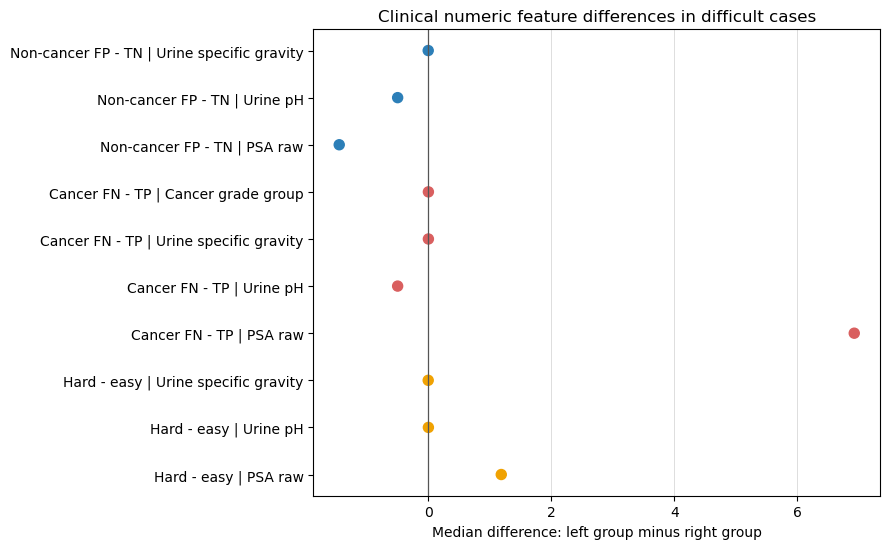

In [5]:
selected = numeric.loc[numeric['scope'].isin(['cancer_fn_vs_tp', 'non_cancer_fp_vs_tn', 'hard_vs_easy'])].copy()
scope_names = {'cancer_fn_vs_tp': 'Cancer FN - TP', 'non_cancer_fp_vs_tn': 'Non-cancer FP - TN', 'hard_vs_easy': 'Hard - easy'}
selected['scope_label'] = selected['scope'].map(scope_names)
fig, ax = plt.subplots(figsize=(9, 5.6))
y = np.arange(len(selected))
colors = selected['scope'].map({'cancer_fn_vs_tp': '#d95f5f', 'non_cancer_fp_vs_tn': '#2c7fb8', 'hard_vs_easy': '#f0a202'})
ax.scatter(selected['median_delta_left_minus_right'], y, c=colors, s=52)
ax.axvline(0, color='#555555', linewidth=0.9)
ax.set_yticks(y, selected['scope_label'] + ' | ' + selected['feature_label'])
ax.set_xlabel('Median difference: left group minus right group')
ax.set_title('Clinical numeric feature differences in difficult cases')
ax.grid(axis='x', color='#dddddd', linewidth=0.7)
ax.set_axisbelow(True)
fig.tight_layout()
fig.savefig(OUTPUT / 'fig01_numeric_feature_differences.png', dpi=180)
plt.show()

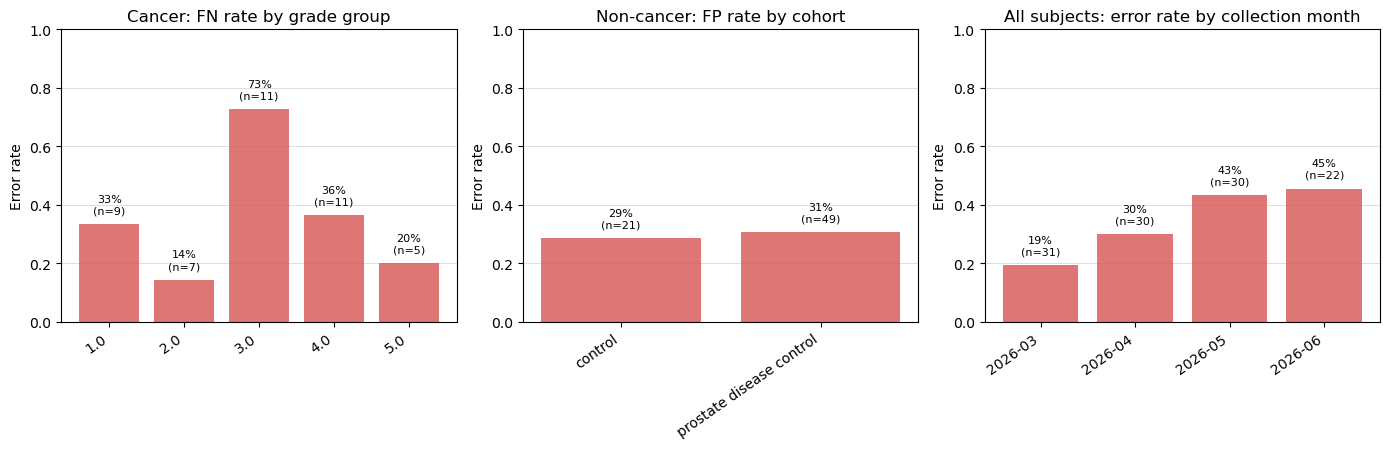

In [6]:
panels = [('cancer_fn_vs_tp', 'grade_group', 'Cancer: FN rate by grade group'), ('non_cancer_fp_vs_tn', 'cohort_group', 'Non-cancer: FP rate by cohort'), ('all_error_vs_correct', 'collection_month', 'All subjects: error rate by collection month')]
fig, axes = plt.subplots(1, 3, figsize=(14, 4.6))
for ax, (scope, feature, title) in zip(axes, panels, strict=True):
    rows = categorical.loc[categorical['scope'].eq(scope) & categorical['feature'].eq(feature)].sort_values('category').copy()
    x = np.arange(len(rows))
    ax.bar(x, rows['left_category_rate'], color='#d95f5f', alpha=0.86)
    ax.set_xticks(x, rows['category'], rotation=35, ha='right')
    ax.set_ylim(0, 1)
    ax.set_title(title)
    ax.set_ylabel('Error rate')
    ax.grid(axis='y', color='#dddddd', linewidth=0.7)
    ax.set_axisbelow(True)
    for xpos, rate, left_n, right_n in zip(x, rows['left_category_rate'], rows['n_left_category'], rows['n_right_category'], strict=True):
        ax.text(xpos, min(rate + 0.03, 0.97), f'{rate:.0%}\n(n={left_n + right_n})', ha='center', va='bottom', fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT / 'fig02_categorical_feature_profiles.png', dpi=180, bbox_inches='tight')
plt.show()

In [7]:
disease_control = categorical.loc[categorical['scope'].eq('non_cancer_fp_vs_tn') & categorical['feature'].eq('cohort_group') & categorical['category'].eq('prostate disease control')].iloc[0]
control = categorical.loc[categorical['scope'].eq('non_cancer_fp_vs_tn') & categorical['feature'].eq('cohort_group') & categorical['category'].eq('control')].iloc[0]
grade_three = categorical.loc[categorical['scope'].eq('cancer_fn_vs_tp') & categorical['feature'].eq('grade_group') & categorical['category'].eq('3.0')].iloc[0]
psa_row = numeric.loc[numeric['scope'].eq('cancer_fn_vs_tp') & numeric['feature'].eq('psa_raw')].iloc[0]
summary = {'data_source': {'database': database_name, 'clinical_tables': ['master.subjects', 'master.samples', 'master.sites', 'clinical.diagnoses', 'clinical.observations']}, 'model_artifacts': {'predictions': PREDICTIONS.name, 'qc_noise': NOISE.name}, 'subjects': int(len(joined)), 'errors': int(joined['error_group'].eq('error').sum()), 'hard_cases': int(joined['hard_case'].sum()), 'cancer_fn_vs_tp': {'psa_raw_median_fn': float(psa_row['median_left']), 'psa_raw_median_tp': float(psa_row['median_right']), 'grade_group_3_fn_rate': float(grade_three['left_category_rate']), 'grade_group_3_n': int(grade_three['n_left_category'] + grade_three['n_right_category'])}, 'non_cancer_fp_vs_tn': {'disease_control_fp_count': int(disease_control['n_left_category']), 'disease_control_fp_rate': float(disease_control['left_category_rate']), 'control_fp_count': int(control['n_left_category']), 'control_fp_rate': float(control['left_category_rate'])}, 'limitations': ['overall_stage missing', 'parsed PSA missing', 'sex constant', 'site constant', 'exploratory comparisons']}
(OUTPUT / 'feature_extraction_summary.json').write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding='utf-8')
report_lines = ['# Clinical feature extraction for poorly distinguished SERS patients', '', f"Clinical fields were queried directly from the `{database_name}` PostgreSQL operational tables. OOF predictions and QC/noise summaries are frozen model-run artifacts. The analysis covers {len(joined)} subjects; error means FP or FN, and hard case means error or OOF probability within 0.05 of threshold 0.40.", '', '## Extracted patterns', '', f"- Cancer grade group 3 has FN rate {grade_three['left_category_rate']:.1%} ({int(grade_three['n_left_category'])}/{int(grade_three['n_left_category'] + grade_three['n_right_category'])}); this is a small exploratory stratum.", f"- Prostate disease controls contribute {int(disease_control['n_left_category'])} FP rows, but their within-category FP rate is {disease_control['left_category_rate']:.1%}, close to {control['left_category_rate']:.1%} in controls.", f"- Cancer FN PSA median is {psa_row['median_left']:.2f} versus {psa_row['median_right']:.2f} for TP; the complete test table contains p-values and q-values.", '- Collection month and urine microscopy are sensitivity profiles that may reflect acquisition or cohort composition.', '', '## Limitations', '', 'Overall stage and parsed PSA are entirely missing, while sex and site are constant. These are descriptive OOF comparisons with small subgroup sizes and do not establish causality.']
(OUTPUT / 'clinical_feature_extraction_report.md').write_text('\n'.join(report_lines), encoding='utf-8')
display(pd.DataFrame(summary['cancer_fn_vs_tp'], index=['value']).T)
display(pd.DataFrame(summary['non_cancer_fp_vs_tn'], index=['value']).T)

,value
psa_raw_median_fn,17.450000
psa_raw_median_tp,10.525000
grade_group_3_fn_rate,0.727273
grade_group_3_n,11.000000


,value
disease_control_fp_count,15.000000
disease_control_fp_rate,0.306122
control_fp_count,6.000000
control_fp_rate,0.285714
